1) PROCESAMIENTO DE LMPIEZA DE DATOS

In [1]:
# IMPORTACIONES GLOBALES
import pandas as pd
import re
import nltk
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Descargar recursos de NLTK
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

print("✅ Todas las librerías importadas correctamente.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ Todas las librerías importadas correctamente.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
# 1.1 Crear listas de mensajes
spam = [
    "¡Felicidades! Has ganado un iPhone 13. Reclama tu premio en: http://bit.ly/win-iphone",
    "Urgente: Tu cuenta bancaria ha sido suspendida. Verifica tus datos aquí: https://bancoseguro.com",
    "Gana dinero rápido trabajando desde casa. Únete ahora: www.trabajo-facil.com",
    "Promoción exclusiva: 50% de descuento en relojes de lujo. Compra hoy: tiendaonline.com",
    "Te has inscrito en un sorteo. Para cancelar, envía 'BAJA' al 55555",
    "Hola, soy abogado y tengo una herencia para ti. Contáctame: herencia@mail.com",
    "Tu suscripción a Netflix está por vencer. Actualiza tu método de pago: netflix-renovar.com",
    "Oferta limitada: Cursos online con certificado. Solo hoy 99€. Accede: cursosya.com",
    "Gana una tarjeta de regalo de Amazon por contestar esta encuesta: encuesta-premio.com",
    "Señor/a, su paquete no pudo ser entregado. Confirme dirección aquí: dhl-reentrega.com",
    "¡Has sido seleccionado para probar productos gratis! Regístrate: muestrasgratis.net",
    "Inversión segura con 200% de ganancia en 1 mes. Informes: inversion@segura.com",
    "Tus fotos privadas han sido publicadas. Mira el enlace para eliminarlas: verguenza.com",
    "Gana hasta 500€ al día con este método secreto. Descarga el PDF: metodorapido.com",
    "Hola, soy de Microsoft. Detectamos virus en tu PC. Llámanos al 900-111-222",
    "Suscripción renovada automáticamente. Si no deseas pagar, cancela aquí: cancelaya.com",
    "Oportunidad de negocio: Vende nuestros productos y gana comisiones. Infórmate: negocioya.com",
    "No te pierdas los mejores chistes diarios. Suscríbete enviando ALTA al 12345",
    "Premio especial: Cena para dos en restaurante de lujo. Confirma asistencia: cena-premio.com",
    "¡Oferta de último minuto! Vuelos a cualquier destino por 49€. Reserva: vuelosbaratos.com"
]

ham = [
    "Hola, ¿qué tal? ¿Quedamos para comer mañana?",
    "Mamá, ya salí del trabajo. Llego en 20 minutos.",
    "Recuerda la reunión de mañana a las 10:00 en la sala 3.",
    "Te adjunto el informe que me pediste. Revísalo y dime qué tal.",
    "¿Puedes comprar pan y leche de camino a casa?",
    "Felicidades por tu nuevo trabajo. ¡Me alegro mucho por ti!",
    "El partido del domingo es a las 5 de la tarde. ¿Vienes?",
    "Te envié la tarea por correo. Cualquier duda me dices.",
    "Hola, soy Juan. ¿Tienes el número de Pedro?",
    "Cita con el dentista el jueves a las 11:30. No olvides.",
    "¿Qué película quieres ver esta noche? Podemos alquilar una.",
    "El paquete de Amazon llegó. Está en la recepción.",
    "Hoy es el cumpleaños de Ana. ¿Le compramos algo juntos?",
    "Te mando la dirección de la fiesta: Calle Mayor 23.",
    "¿Me prestas tus apuntes de historia? Gracias.",
    "La cena familiar se adelanta a las 8. Confirma asistencia.",
    "Hemos quedado en el bar de siempre a las 7.",
    "Te escribo para recordarte que mañana hay huelga de metro.",
    "¿Viste el partido anoche? Increíble final.",
    "Te adjunto las fotos de las vacaciones. ¡Qué recuerdos!"
]

# Aquí se crea el DataFrame
mensajes = spam + ham
etiquetas = ['spam']*20 + ['ham']*20
df = pd.DataFrame({'mensaje': mensajes, 'clase': etiquetas})

# Esta es la función de limpieza
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto, flags=re.MULTILINE)
    texto = re.sub(r'@\w+', '', texto)
    texto = re.sub(r'[^a-zA-Záéíóúüñ\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Aquí se aplica limpieza
df['mensaje_limpio'] = df['mensaje'].apply(limpiar_texto)

# Mostrar resultados
print("Paso 1 completado. Muestra de mensajes limpios:")
print(df[['mensaje', 'mensaje_limpio']].head(10))

Paso 1 completado. Muestra de mensajes limpios:
                                             mensaje  \
0  ¡Felicidades! Has ganado un iPhone 13. Reclama...   
1  Urgente: Tu cuenta bancaria ha sido suspendida...   
2  Gana dinero rápido trabajando desde casa. Únet...   
3  Promoción exclusiva: 50% de descuento en reloj...   
4  Te has inscrito en un sorteo. Para cancelar, e...   
5  Hola, soy abogado y tengo una herencia para ti...   
6  Tu suscripción a Netflix está por vencer. Actu...   
7  Oferta limitada: Cursos online con certificado...   
8  Gana una tarjeta de regalo de Amazon por conte...   
9  Señor/a, su paquete no pudo ser entregado. Con...   

                                      mensaje_limpio  
0  felicidades has ganado un iphone reclama tu pr...  
1  urgente tu cuenta bancaria ha sido suspendida ...  
2  gana dinero rápido trabajando desde casa únete...  
3  promoción exclusiva de descuento en relojes de...  
4  te has inscrito en un sorteo para cancelar env...  
5  ho

2) TOKENIZACIÓN Y ELIMINACION DE STOPWORDS

In [4]:
# Asegurar que el recurso para tokenizar está disponible
nltk.download('punkt_tab')

# Obtener stopwords en español
stop_words_es = set(stopwords.words('spanish'))

# Función para tokenizar y eliminar stopwords
def tokenizar_sin_stopwords(texto):
    tokens = word_tokenize(texto, language='spanish')
    tokens_filtrados = [word for word in tokens if word not in stop_words_es and len(word) > 1]
    return ' '.join(tokens_filtrados)

# Aplicar tokenización
df['mensaje_procesado'] = df['mensaje_limpio'].apply(tokenizar_sin_stopwords)

# Mostrar resultados
print("Paso 2 completado. Mensajes después de tokenización y stopwords:")
print(df[['mensaje_limpio', 'mensaje_procesado']].head(10))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Paso 2 completado. Mensajes después de tokenización y stopwords:
                                      mensaje_limpio  \
0  felicidades has ganado un iphone reclama tu pr...   
1  urgente tu cuenta bancaria ha sido suspendida ...   
2  gana dinero rápido trabajando desde casa únete...   
3  promoción exclusiva de descuento en relojes de...   
4  te has inscrito en un sorteo para cancelar env...   
5  hola soy abogado y tengo una herencia para ti ...   
6  tu suscripción a netflix está por vencer actua...   
7  oferta limitada cursos online con certificado ...   
8  gana una tarjeta de regalo de amazon por conte...   
9  señora su paquete no pudo ser entregado confir...   

                                   mensaje_procesado  
0           felicidades ganado iphone reclama premio  
1  urgente cuenta bancaria sido suspendida verifi...  
2     gana dinero rápido trabajando casa únete ahora  
3  promoción exclusiva descuento relojes lujo com...  
4                inscrito sorteo cancelar e

3) ENTRENAMIENTO DEL MODELO

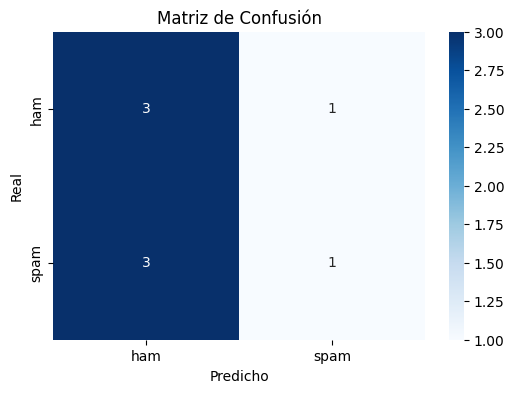

Reporte de clasificación:
              precision    recall  f1-score   support

         ham       0.50      0.75      0.60         4
        spam       0.50      0.25      0.33         4

    accuracy                           0.50         8
   macro avg       0.50      0.50      0.47         8
weighted avg       0.50      0.50      0.47         8

✅ Modelo y vectorizador guardados en disco.


In [5]:
# Se separan características y etiquetas
X = df['mensaje_procesado']
y = df['clase']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Vectorización TF-IDF
vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Entrenar modelo
modelo = MultinomialNB()
modelo.fit(X_train_tfidf, y_train)

# Predicciones y evaluación
y_pred = modelo.predict(X_test_tfidf)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

# Reporte de clasificación
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

# Guardar modelo y vectorizador
joblib.dump(modelo, 'modelo_spam.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')
print("✅ Modelo y vectorizador guardados en disco.")

4) HACER PREDICCIONES EN TIEMPO REAL

In [11]:
# Función de predicción con nivel de confianza
def predecir_mensaje(texto_nuevo):
    limpio = limpiar_texto(texto_nuevo)
    procesado = tokenizar_sin_stopwords(limpio)
    vectorizado = vectorizer.transform([procesado])
    prediccion = modelo.predict(vectorizado)[0]
    probabilidades = modelo.predict_proba(vectorizado)[0]
    confianza = max(probabilidades) * 100
    return prediccion, confianza

# Ejemplos de uso
mensaje1 =  "Te has inscrito en un sorteo. Para cancelar, envía 'BAJA' al 55555"
resultado, conf = predecir_mensaje(mensaje1)
print(f"Mensaje: {mensaje1}")
print(f"Predicción: {resultado.upper()}")
print(f"Confianza: {conf:.2f}%\n")

Mensaje: Te has inscrito en un sorteo. Para cancelar, envía 'BAJA' al 55555
Predicción: SPAM
Confianza: 67.40%

